In [17]:
from qsopt import * 
import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import qutip

print(f"JAX version: {jax.__version__}")
print(f"QuTiP version: {qutip.__version__}")
print(f"JAX backend: {jax.default_backend()}")
devices = jax.devices()
print(f"JAX devices: {devices}")
print(f"JAX GPU available: {any(d.platform == 'gpu' for d in devices)}")

JAX version: 0.9.2
QuTiP version: 5.2.2
JAX backend: cpu
JAX devices: [CpuDevice(id=0)]
JAX GPU available: False


## Define experimental parameters

In [18]:
sigma = 1
k = 15 * sigma

from jax.scipy.special import erfc

def pulse(t, **kwargs):
    """
    Time-dependent coupling function for input cavity transparency.

    Args:
        t: float or JAX array, time variable
        **kwargs: Dictionary containing 'sigma' parameter (pulse bandwidth)

    Returns:
        JAX array: Normalized coupling strength g(t)
    """
    sigma = kwargs.get("sigma", 1.0)
    # exp(-x^2)/erfc(x) is a numerical 0/0 for large x (both underflow) -> NaN. The photon wavepacket
    # is at t~0 (width ~1/sigma), so clamping the argument to |x|<=8 keeps the coupling finite far
    # past the pulse instead of diverging, without changing anything in the physical region.
    dx = jnp.clip(sigma * t, -8.0, 8.0)
    coupling = jnp.sqrt(2 * sigma / jnp.sqrt(jnp.pi) * jnp.exp(-(dx**2)) / erfc(dx))
    return jnp.array(coupling, float)

# Define interactions
interactions = [
    Interaction(interaction_type = InteractionType.DISPERSIVE,
                subsystem1 = ('cavity',0),
                subsystem2 = ('qubit',0),
                parameters = {'chi':0.5*k}
                )
]

# Define custom physical model
physical_model = PhysicalModel(
    perturbation_type = 'transient',
    n_cavities = 1,
    n_fields = 1,
    n_qubits = 1,
    cavity_levels = 2,
    field_levels = 2,
    qubit_levels = 2,
    interactions = interactions
)


# Define noise model
noise = NoiseModel(
    depolarizing=0.01,
    dephasing=0.01,
    relaxation=0.01
)

# Define measurement protocol
custom_times = TimeProtocol(
    t_simulation_start=-6,
    n_measurements=4,
    time_interval=4,
    random_measurements_offset=True,
    noisy_simulation_start=True
)

config_set = [
    SystemConfiguration(
        name = 'no interaction',
        init_field_states = {0: SubsystemState(State.FOCK, {'n':0})},
        is_ground = True),
    SystemConfiguration(
        name = 'with interaction',
        init_field_states = {0: SubsystemState(State.FOCK, {'n':1})},
        interactions = [            
    Interaction(interaction_type = InteractionType.INPUT_OUTPUT,
            subsystem1 = ('cavity',0),
            subsystem2 = ('field',0),
            parameters = {'gamma':1, 'kappa':k, 'sigma': sigma},
            time_modulation = pulse
            ),
        ]),
]

# Create parameters with custom configuration
exp_parameters = ExperimentalParameters(
    physical_model=physical_model,
    noise_model=noise,
    time_protocol=custom_times,
    configuration_set=config_set
)

print(exp_parameters)

SYSTEM DIMENSIONS
  Cavities: 1   levels [2]
  Fields:   1   levels [2]
  Qubits:   1   levels [2]
  Total dimension: 8

PHYSICAL MODEL
  Perturbation type:    transient
  Interactions:         4 interaction(s)
  Static interactions:
    dispersive(cavity0-qubit0): chi=7.5
    depolarizing(qubit0): depolarizing=0.01
    dephasing(qubit0): dephasing=0.01
    relaxation(qubit0): relaxation=0.01

TIME PROTOCOL
  Start time:            -6.0000
  Mode:                 Interval-based
  Time interval:          4.0000
  Number of measurements:      4
  Computed times:       [-2.0, 2.0, 6.0, 10.0]
  Collective offset:    uniform(-4, 0)
  Per-measurement jitter: none
  Noisy simulation start: on
  Measurement window:   None (uniform weights)

NOISE MODEL
  Depolarizing rate:    [0.01]
  Dephasing rate:       [0.01]
  Relaxation rate:      [0.01]
  Custom operators:     None

CONFIGURATIONS
  Count:                2
  Ground configuration: no interaction
    [0] no interaction (ground): noise_ove

## Optional, plot pulse shape

In [19]:
# from qsopt.utils.visualization import plot_pulse_shape_with_measurements

# fig = plot_pulse_shape_with_measurements(
#     exp_params=exp_parameters,
#     save_path='results/pulse_shape.png',
#     batch_size=1
# )
# fig.show()

## Define quantum circuits

The interface uses `QuantumCircuit` objects to define the gates applied before and after evolution.

In [20]:
import copy
from qsopt.core.circuit import create_ry_circuit

initial_circuit = create_ry_circuit(n_qubits=1, theta_values=[np.pi/2])
final_circuit = create_ry_circuit(n_qubits=1, theta_values=[-np.pi/2])

# The circuits contain trainable parameters that will be optimized
print(f"Initial circuit parameters: {initial_circuit.get_trainable_parameters()}")
print(initial_circuit)
print(f"Final circuit parameters: {final_circuit.get_trainable_parameters()}")
print(final_circuit)

Initial circuit parameters: [Array(1.57079633, dtype=float64)]
QuantumCircuit(1 qubits, 1 gates)
  0: RY[0](param=1.571)
Final circuit parameters: [Array(-1.57079633, dtype=float64)]
QuantumCircuit(1 qubits, 1 gates)
  0: RY[0](param=-1.571)


## Define experiment

In [21]:
detection_metric = DetectionMetric(n_cavities=1,
                                   n_fields=1,
                                   n_qubits=1,
                                   config_names=['with interaction','no interaction'],
                                   detection_criterion = 'max computational distance',
                                   perturbation_type=physical_model.perturbation_type
                                   )

print(detection_metric)

experiment = Experiment(
    experimental_params=exp_parameters,
    initial_circuit=initial_circuit,
    final_circuit=final_circuit,
    detection_metric=detection_metric
)


DetectionMetric:
maximize computational distance
softmax aggregation, transient



## Test Single Simulation

In [22]:
# run_simulation returns the metrics (metric, validation, per-configuration detection). The deployable
# detection protocol (states map, joint confusion matrix, false signal and full probability tree) is
# built by make_protocol from the branching simulation.
results = experiment.run_simulation(batch_size=16)
print(results)

protocol = experiment.make_protocol(batch_size=16)
print(protocol)

MODE: Single Simulation
  Experiment metadata:  absent
  Current Parameters:
     Initial circuit:
        param_0: 1.570796 rad (90.00°)
     Final circuit:
        param_0: -1.570796 rad (-90.00°)
  Detection Measures:
     no interaction   : 0.000000
     with interaction : 0.000000
  Objective:
     Metric:     0.563506
     Validation: 0.563506
MODE: Single Simulation
  Experiment metadata:  absent
  Detection Protocol (states classified per configuration):
     no interaction: ['0']
     with interaction: ['1']
  False signal (joint, per configuration):
     no interaction: 0.2554
     with interaction: 0.0000
  Confusion Matrix (rows: true, cols: predicted):
                           no interaction  with interaction             mixed
         no interaction            0.7446            0.2554            0.0000
       with interaction            0.0592            0.9408            0.0000


## Time Evolution

In [7]:
# result = experiment.time_evolution(n_points=300, with_interaction=True)
# print(result)

# from qsopt.utils.visualization import plot_time_evolution
# plot_time_evolution(
#     evolution_data=result,
#     show_pulse=True,
#     show_measurements=True,
#     show_cavity_population=True,  # Cavity population (purple)
#     show_field_population=True,   # External field population (brown)
#     title='Single Qubit Evolution',
#     figsize=(10, 6),
#     normalize_detection = True
# )
# plt.show()

## Run Optimization

In [8]:
import optax

# Use an explicit callback so this history is not overwritten by later optimizations
history_callback = OptimizationCallback(save_every=1, save_best=True)

history = experiment.optimize_rotations(
    initial_values=[ np.pi/2, -np.pi/2], 
    num_steps=150,
    verbose=True,
    verbose_step=25,
    batch_size=16,
    tolerance=1e-7,
    callback=history_callback,
    optimizer=optax.sgd(learning_rate=0.1),
    anneal_tolerances=1000
)

Configuration:
    Max iterations: 150
    Batch size: 16
    Convergence tolerance: 1.00e-07
    Detection metric:
maximize computational distance
softmax aggregation, transient
    Trainable parameters: 2 (1 initial circuit + 1 final circuit)
    Initial parameter values:
        param0.  setup_RY[0]  = 1.571  rad (90.0°)
        param1.  reset_RY[0]  = -1.571 rad (-90.0°)
    Measurement uncertainty: collective offset uniform(-4, 0), per-measurement jitter off
Step  setup0_RY[0]   reset0_RY[0]   Metric      Validation  Grad Norm   Time
---------------------------------------------------------------------------------
0     1.570796       -1.570796      0.253601    0.754056    3.04e-07    00h00m33s
1     1.570796       -1.570796      0.253633    0.667165    4.79e-07    00h00m34s
2     1.570796       -1.570796      0.255931    0.737657    3.18e-07    00h00m35s
17    1.570797       -1.570796      0.272802    0.784556    6.19e-08    00h00m46s
19    1.570797       -1.570796      0.274935 

In [9]:
# Free GPU/JAX memory after optimization
jax.clear_caches()
import gc; gc.collect()

1186

In [10]:
# make_protocol on a callback loads its best parameters onto the circuits and stores the detection
# protocol (states map, joint confusion matrix, false signal and probability tree) onto it.
history = experiment.make_protocol(callback=history, batch_size=16)
print(history)

MODE: Optimization
     Total iterations: 58
     Best epoch:        52
     Converged: True
     Final gradient norm: 5.585139e-08
  Experiment metadata:  present (use print_metadata())
  Best Parameters:
     Initial circuit:
        param_0: 1.570797 rad (90.00°)
     Final circuit:
        param_0: -1.570796 rad (-90.00°)
  Detection Measures:
     no interaction   : 0.000000
     with interaction : 0.000000
  Objective:
     Metric:     0.704265
     Validation: 0.704265
  Detection Protocol (states classified per configuration):
     no interaction: ['0']
     with interaction: ['1']
  False signal (joint, per configuration):
     no interaction: 0.0301
     with interaction: 0.0000
  Confusion Matrix (rows: true, cols: predicted):
                           no interaction  with interaction             mixed
         no interaction            0.9699            0.0301            0.0000
       with interaction            0.0112            0.9888            0.0000


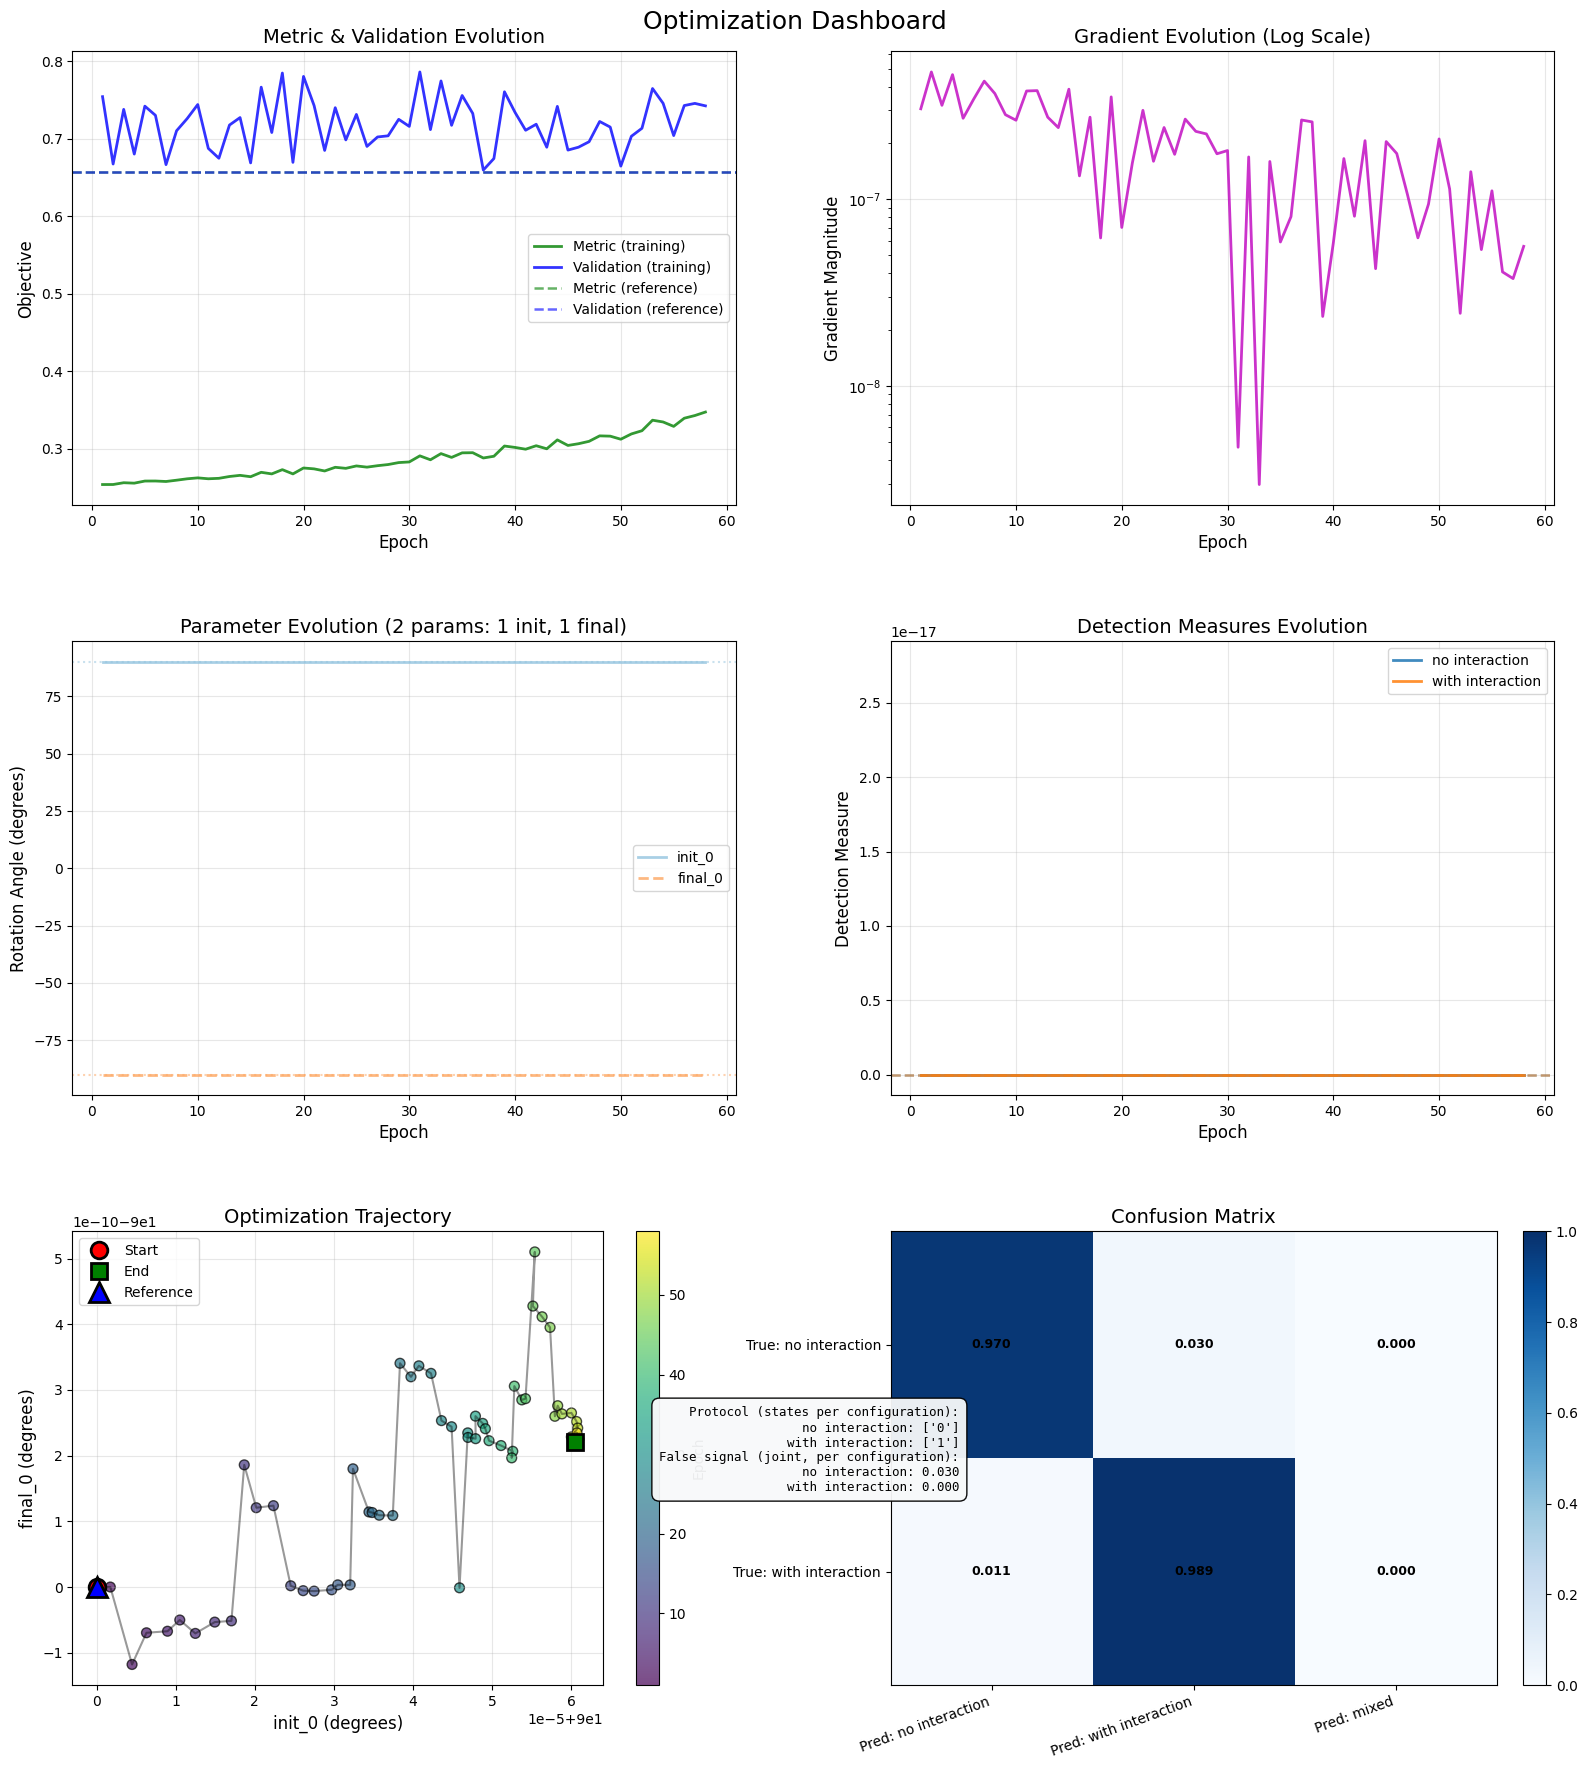

In [11]:
from qsopt.utils.visualization import plot_optimization_dashboard

# Create comprehensive dashboard with all plots enabled
fig = plot_optimization_dashboard(
    optimization_callback=history,
    reference_callback=results,
    show_metric=True,
    show_gradients=True,
    show_parameters=True,
    show_detection_measures=True,
    show_trajectory=True,
    show_confusion_matrix_summary=True,
    save_path='results/rotations_opt_dashboard.pdf'  # Save to file
)

plt.show()

## Sweep Measurement Times

In [35]:
# Sweep over 'time_interval': it re-spaces the M measurements as t0 + [0, v, ..., M*v] for each interval
# v. A measurement-times sweep needs a fixed measurement WINDOW so the metric is scored over the same
# region of interest as the spacing changes; the sweep also requires the measurements to span the window
# (M*min(v) >= window_end - t0). Here t0 = t_simulation_start = -10 and the input pulse diverges for large
# positive t, so the interval is bounded below (span check) and above (measurements stay <~ 10): v in [3.2, 4.0].
windowed_protocol  = TimeProtocol(
    t_simulation_start=-4,
    n_measurements=20,
    time_interval=4,
    random_measurements_offset=True,
    per_measurement_jitter=0.01,
    noisy_simulation_start=True,
    window_start= -2,
    window_end=8
)
results_time_sweep = experiment.sweep(
    {'time_interval': np.linspace(0.75, 12.0, 20)},
    time_protocol=windowed_protocol,
    batch_size=128,
    verbose=True
)
print(results_time_sweep)

Sweeping 1 axes over 20 grid points (uncertainty on, 128 realizations/point):
  - time_interval: 20 pts in [0.75, 12]  lane=measurement  (measurement times)
Best metric 0.676359 at {'time_interval': 6.078947368421052}
SweepResults:
  Axis 0 (time_interval): [0.75, 12], linear, 20 points
  Available results: detection_no interaction, detection_with interaction, metric, validation


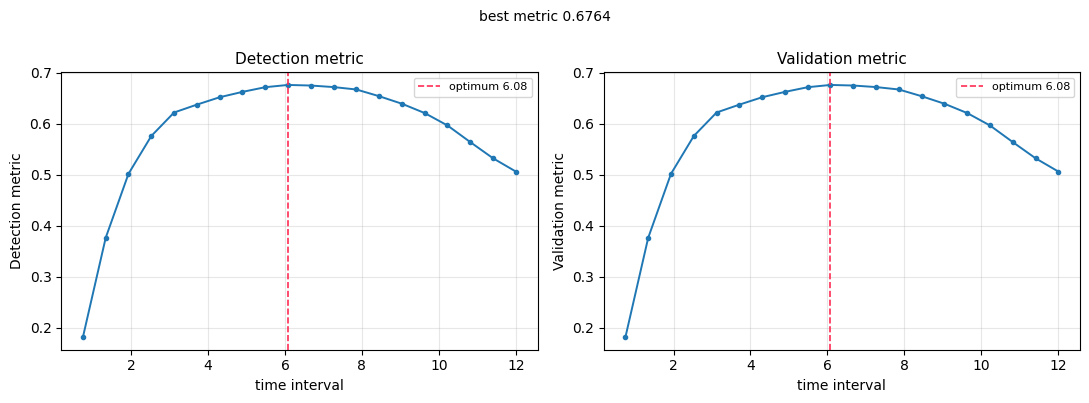

In [36]:
from qsopt.utils.visualization import plot_sweep_results

# A 1D sweep draws one line per selected quantity. metric / validation / detection are each
# togglable (all True by default); here we hide the per-configuration detection lines.
plot_sweep_results(results_time_sweep, show_detection=False, figsize=(11, 4))
plt.show()

## Sweep chi-kappa

In [14]:
# The generic N-D sweep takes a {parameter_name: values} grid. 'chi' is the dispersive coupling, 'gamma'
# the input-output coupling of the 'with interaction' config. Each grid point returns the metric,
# validation and per-configuration detection.
results_sweep = experiment.sweep(
    {'chi': np.linspace(1.0, 20.0, 10), 'kappa': np.linspace(1.0, 40.0, 10)},
    batch_size=1,
    verbose=True
)
print(results_sweep)

/home/nathan/Documenti/Università/Magistrale/Tesi Magistrale/Quantum-sensing-QML/src/qsopt/core/experiment/experiment.py:1582: UserWarning: batch_size=1 is too small to average measurement uncertainty consistently; using 16 instead.
  warnings.warn(f"batch_size={batch_size} is too small to average measurement uncertainty "


Sweeping 2 axes over 100 grid points (uncertainty on, 16 realizations/point):
  - chi: 10 pts in [1, 20]  lane=promote  (BaseModel_dispersive(cavity0,qubit0)__chi)
  - kappa: 10 pts in [1, 40]  lane=rebuild  (Conf:with interaction_input_output(cavity0,field0)__kappa)
Best metric 0.63666 at {'chi': 3.111111111111111, 'kappa': 5.333333333333333}
SweepResults:
  Axis 0 (chi): [1, 20], linear, 10 points
  Axis 1 (kappa): [1, 40], linear, 10 points
  Available results: detection_no interaction, detection_with interaction, metric, validation


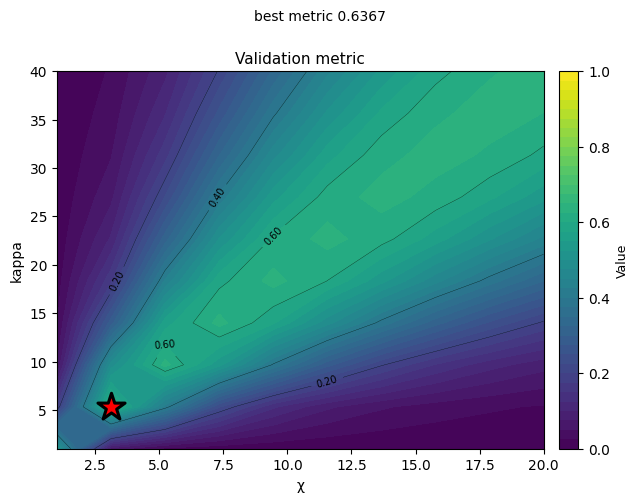

In [15]:
from qsopt.utils.visualization import plot_sweep_results

# A 2D sweep draws one contour panel per selected quantity (metric, validation and each detection
# config). 'display_axes' chooses which axes go on x/y (defaults to the first two); toggle the
# quantities with show_metric / show_validation / show_detection.
plot_sweep_results(results_sweep, show_detection=False, show_metric=False)
plt.show()

## Sweep in more than two dimensions

`experiment.sweep` takes any number of axes. Below we sweep four at once: the pulse bandwidth `sigma`, the input–output rate `kappa` (the `k` of the INPUT_OUTPUT interaction), the dispersive coupling `chi`, and the measurement `time_interval`.

A scalar map over 4 axes can't be drawn directly, so there are three views:

- **`plot_sweep_results`** shows a *slice*: it plots one or two axes and fixes the rest at the optimum (or at values you pass via `fixed={'axis': value}`).
- **`plot_sweep_corner`** shows *every axis pair at once* — upper triangle slices through the optimum, lower triangle max-projects over the hidden axes, diagonal is the 1D max-projection per axis.
- **`interactive_sweep`** is a live explorer (`ipywidgets`) with a slider per hidden axis.

In [16]:
# 4D sweep: sigma (pulse bandwidth), kappa (the 'k' of the INPUT_OUTPUT interaction), chi (dispersive
# coupling) and the measurement time_interval. Kept small (4 points/axis) so it runs quickly — raise
# the resolutions for smoother maps. Reuses windowed_protocol from the measurement-times sweep above,
# since a time_interval axis needs a fixed measurement window.
results_hd = experiment.sweep(
    {
        'sigma': np.linspace(0.6, 1.4, 4),
        'kappa': np.linspace(8.0, 20.0, 4),
        'chi': np.linspace(1.0, 20.0, 4),
        'time_interval': np.linspace(3.2, 4.0, 4),
    },
    measurement_protocol=windowed_protocol,
    batch_size=1,
    verbose=True,
)
print(results_hd)

TypeError: Experiment.sweep() got an unexpected keyword argument 'measurement_protocol'

### Corner view — every axis pair at once

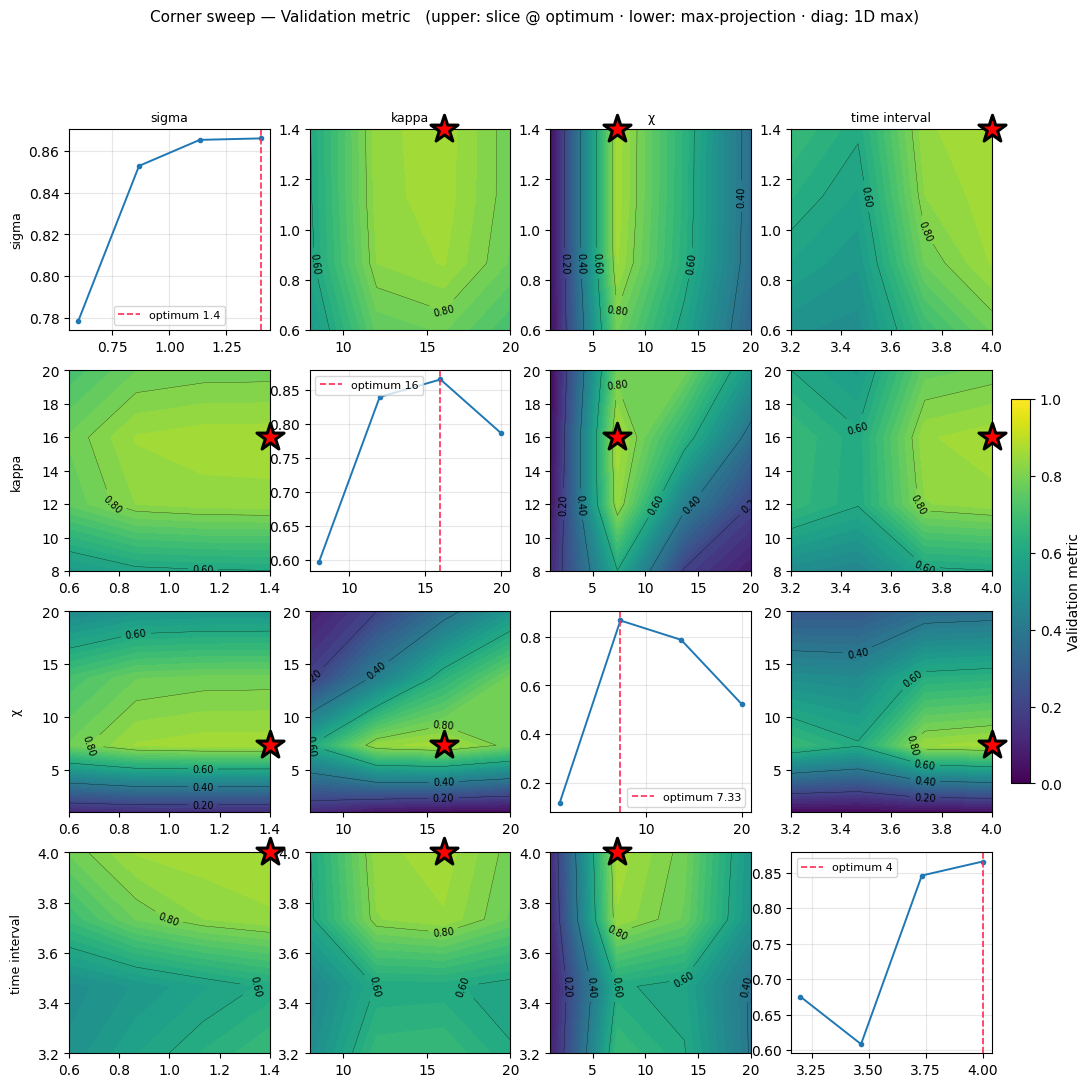

In [ ]:
from qsopt.utils.visualization import plot_sweep_corner

# One quantity across every axis pair. Upper triangle: 2D slice through the optimum. Lower triangle:
# max-projection over the hidden axes. Diagonal: 1D max-projection. Choose the map with
# quantity='metric' | 'validation' | 'detection' (and config=<name> for detection).
plot_sweep_corner(results_hd, quantity='validation')
plt.show()

### Interactive explorer

In [ ]:
from qsopt.utils.visualization import interactive_sweep

# Live explorer (needs ipywidgets, installed with the package). Dropdowns pick the quantity and the
# two shown axes; a slider per remaining axis moves the slice. Set 'hidden' to max/mean to project
# over the hidden axes instead of slicing.
interactive_sweep(results_hd)